<a href="https://colab.research.google.com/github/karol-duda/dss_thesis_aml_shap/blob/main/notebooks/02_baseline_sprint3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Sprint 3: Model Ladder, Comprehensive Evaluation & SHAP Foundation
Author: Karol Duda
Project: Measuring and Controlling SHAP Explanation Instability in High-Stakes AML Systems

Executive Summary
This notebook implements the full three-stage model complexity ladder and establishes the
SHAP evaluation foundation required for Sprint 4. Key deliverables:

1.Frozen Dataset Loading: The train_processed.parquet artifact from Sprint 1 is loaded
without any modification — it serves as the immutable experimental substrate.

2.Model Ladder: Three progressive models (Logistic Regression → XGBoost raw →
XGBoost + Magic Features) establish a scientific narrative of increasing complexity.

3.Comprehensive Evaluation: Every model is evaluated with the same function producing
PR-AUC, ROC-AUC, Confusion Matrix, Precision, Recall, and F1 — demonstrating
why PR-AUC is the correct primary metric for this task.

4.RQ2 Setup: An XGBoost variant trained with scale_pos_weight is introduced as the
weighted condition for the class-imbalance diagnostic experiment.

5.SHAP Foundation: A TreeSHAP analysis on the reference model (seed = 42) establishes
the explanatory baseline from which Sprint 4's stability experiments will depart.

In [ ]:
# ============================================================
# SPRINT 3 — SETUP & IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import shap
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)
from google.colab import drive

drive.mount('/content/drive')

plt.style.use('ggplot')
sns.set_palette("muted")

# Pin versions for reproducibility — to be logged thesis appendix
print(f"XGBoost  : {xgb.__version__}")
print(f"SHAP     : {shap.__version__}")
print(f"Pandas   : {pd.__version__}")
print("Environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
XGBoost  : 3.2.0
SHAP     : 0.51.0
Pandas   : 2.2.2
Environment ready.


##1. Data Loading & Out-of-Time Split
The frozen dataset from Sprint 1 is loaded. No feature engineering is performed here.
Any modification of the parquet artifact would invalidate the reproducibility guarantee.

In [ ]:
# ============================================================
# LOAD FROZEN ARTIFACT Sprint 1 output
# ============================================================
PATH = '/content/drive/MyDrive/'

print("Loading frozen dataset artifact...")
train = pd.read_parquet(f'{PATH}train_processed.parquet')

# Convert any remaining object columns to category
# (Parquet preserves most dtypes but category may revert to object on some versions)
for col in train.columns:
    if train[col].dtype.name == 'category' or train[col].dtype == 'object':
        train[col] = pd.factorize(train[col])[0].astype('int16')

# --------------------------------------------------------
# DEFINE FEATURE SETS
# --------------------------------------------------------
# cols_base: raw features + basic frequency encoding (no UID behavioral aggregates)
# Excludes: uid-based aggregations, target, time index
cols_base = [
    c for c in train.columns
    if '_uid_' not in c
    and c not in ['isFraud', 'TransactionDT', 'uid_FE', 'outsider15']
]

# cols_adv: full feature set including 6 UID behavioral aggregates from Sprint 1
cols_adv = [c for c in train.columns if c not in ['isFraud', 'TransactionDT']]

y = train['isFraud'].copy()

# --------------------------------------------------------
# STRICT OUT-OF-TIME SPLIT (75% train / 25% validation)
# Sorted chronologically — never use random shuffle on time series data
# --------------------------------------------------------
train.sort_values('TransactionDT', inplace=True)
split_idx = int(len(train) * 0.75)
idxT = train.index[:split_idx]
idxV = train.index[split_idx:]

fraud_rate_train = y.loc[idxT].mean()
fraud_rate_val   = y.loc[idxV].mean()

print(f"\nOOT Split complete.")
print(f"  Training   : {len(idxT):,} rows | fraud rate = {fraud_rate_train:.3%}")
print(f"  Validation : {len(idxV):,} rows | fraud rate = {fraud_rate_val:.3%}")
print(f"\nFeature counts:")
print(f"  Baseline (cols_base) : {len(cols_base)} features")
print(f"  Advanced (cols_adv)  : {len(cols_adv)} features")
print(f"  UID behavioral delta : {len(cols_adv) - len(cols_base)} features")

Loading frozen dataset artifact...

OOT Split complete.
  Training   : 442,905 rows | fraud rate = 3.514%
  Validation : 147,635 rows | fraud rate = 3.454%

Feature counts:
  Baseline (cols_base) : 434 features
  Advanced (cols_adv)  : 440 features
  UID behavioral delta : 6 features


##2. Universal Evaluation Framework
A single function evaluates every model in this notebook, ensuring strict comparability.
The threshold is set to the value that maximises F1-score on the validation set — this
simulates a calibrated operational decision point, as opposed to an arbitrary 0.5 cutoff.

In [ ]:
# ============================================================
# UNIVERSAL EVALUATION FUNCTION
# ============================================================
def evaluate_model(model_name, y_true, y_pred_proba, color='steelblue',
                   ax_pr=None, ax_roc=None):
    """
    Computes and prints a full evaluation suite for a single model.
    Returns a results dict for the comparison table.
    Optionally plots onto provided axes objects for overlay plots.
    """
    # ---- Threshold-free metrics ----
    pr_auc  = average_precision_score(y_true, y_pred_proba)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    # ---- Find F1-optimal threshold ----
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_proba)
    f1_values = (2 * precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx  = np.argmax(f1_values[:-1])   # last element has no threshold
    best_thr  = thresholds[best_idx]

    # ---- Threshold-dependent metrics ----
    y_pred = (y_pred_proba >= best_thr).astype(int)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred,    zero_division=0)
    f1     = f1_score(y_true, y_pred,        zero_division=0)
    cm     = confusion_matrix(y_true, y_pred)

    # ---- Console output ----
    print(f"\n{'='*55}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*55}")
    print(f"  PR-AUC        : {pr_auc:.4f}   ← primary metric")
    print(f"  ROC-AUC       : {roc_auc:.4f}   ← for comparison only")
    print(f"  Threshold (F1-opt): {best_thr:.4f}")
    print(f"  Precision     : {prec:.4f}")
    print(f"  Recall        : {rec:.4f}")
    print(f"  F1-Score      : {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"  TN={cm[0,0]:>6,}  FP={cm[0,1]:>5,}")
    print(f"  FN={cm[1,0]:>6,}  TP={cm[1,1]:>5,}")

    # ---- Optional: plot onto overlay axes ----
    if ax_pr is not None:
        ax_pr.plot(recalls, precisions,
                   label=f'{model_name} (PR-AUC={pr_auc:.3f})',
                   color=color, linewidth=2)

    if ax_roc is not None:
        fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
        ax_roc.plot(fpr, tpr,
                    label=f'{model_name} (ROC-AUC={roc_auc:.3f})',
                    color=color, linewidth=2)

    return {
        'Model'    : model_name,
        'PR-AUC'   : round(pr_auc,  4),
        'ROC-AUC'  : round(roc_auc, 4),
        'Threshold': round(best_thr, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1'       : round(f1,   4),
        'TN'       : cm[0, 0],
        'FP'       : cm[0, 1],
        'FN'       : cm[1, 0],
        'TP'       : cm[1, 1],
    }

# Store all results here for the final comparison table
results = []
print("Evaluation framework loaded.")

Evaluation framework loaded.


##3. Model 1 — Logistic Regression (Interpretable Baseline)
Logistic Regression serves as the structural lower bound. It cannot handle missing values
natively, requires feature scaling, and assumes linear decision boundaries — all of which
are violated by the IEEE-CIS data. The deliberately weak imputation (zero-fill) suppresses
the informative NaN signal. These violations are not experimental errors; they are
the scientific justification for the GBDT architecture.

In [ ]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# Categories were pre-encoded as int16 during the loading phase —
# ============================================================
print("Preparing data for Logistic Regression...")

# Cast to float32 and replace placeholder -1 with actual NaN
# (-1 originates from cat.codes for categorical NaNs; the imputer requires np.nan)
train_lr = train[cols_base].astype('float32').copy()
train_lr.replace(-1, np.nan, inplace=True)

X_train_lr = train_lr.loc[idxT]
X_val_lr   = train_lr.loc[idxV]

# Pipeline: zero-imputation → StandardScaler → Logistic Regression
# class_weight='balanced' handles the 3.5% minority class imbalance
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Logistic Regression...")
lr_pipeline.fit(X_train_lr, y.loc[idxT])

preds_lr = lr_pipeline.predict_proba(X_val_lr)[:, 1]

results.append(evaluate_model(
    'Logistic Regression',
    y.loc[idxV], preds_lr,
    color='gray'
))

# Memory management: Clean up large temporary DataFrames
del train_lr, X_train_lr, X_val_lr
gc.collect()

Preparing data for Logistic Regression...
Training Logistic Regression...

  MODEL: Logistic Regression
  PR-AUC        : 0.1968   ← primary metric
  ROC-AUC       : 0.8284   ← for comparison only
  Threshold (F1-opt): 0.8767
  Precision     : 0.3141
  Recall        : 0.3586
  F1-Score      : 0.3349

  Confusion Matrix:
  TN=138,541  FP=3,994
  FN= 3,271  TP=1,829


27

##4. Model 2 — XGBoost Raw Features (GBDT Baseline)
The XGBoost baseline demonstrates the advantage of tree-based sparsity-aware learning
over linear models on this data structure. Critically, random_state=42 is set here:
this is the reference seed for all subsequent seed perturbation experiments in Sprint 4.

In [ ]:
# ============================================================
# MODEL 2: XGBOOST — RAW FEATURES
# random_state=42 is the fixed reference seed for this entire study
# ============================================================
print("--- Training XGBoost Baseline (Raw Features, seed=42) ---")

clf_xgb_raw = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric='aucpr',
    early_stopping_rounds=150,
    tree_method='hist',
    random_state=42,          #fixed seed for reproducibility
    device='cuda'
)

clf_xgb_raw.fit(
    train.loc[idxT, cols_base], y.loc[idxT],
    eval_set=[(train.loc[idxV, cols_base], y.loc[idxV])],
    verbose=200
)

preds_xgb_raw = clf_xgb_raw.predict_proba(train.loc[idxV, cols_base])[:, 1]

results.append(evaluate_model(
    'XGBoost Raw (seed=42)',
    y.loc[idxV], preds_xgb_raw,
    color='steelblue'
))

--- Training XGBoost Baseline (Raw Features, seed=42) ---
[0]	validation_0-aucpr:0.34816
[200]	validation_0-aucpr:0.56185
[400]	validation_0-aucpr:0.59085
[600]	validation_0-aucpr:0.60051
[800]	validation_0-aucpr:0.60755
[1000]	validation_0-aucpr:0.60981
[1200]	validation_0-aucpr:0.61209
[1400]	validation_0-aucpr:0.61300
[1600]	validation_0-aucpr:0.61450
[1800]	validation_0-aucpr:0.61524
[1892]	validation_0-aucpr:0.61563


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [21:02:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



  MODEL: XGBoost Raw (seed=42)
  PR-AUC        : 0.6158   ← primary metric
  ROC-AUC       : 0.9288   ← for comparison only
  Threshold (F1-opt): 0.0902
  Precision     : 0.6526
  Recall        : 0.5531
  F1-Score      : 0.5987

  Confusion Matrix:
  TN=141,033  FP=1,502
  FN= 2,279  TP=2,821


##5. Model 3 — XGBoost + Magic Features (Advanced Model, Reference)
This is the primary model for the thesis stability analysis. It incorporates the 6 UID
behavioral aggregates from Sprint 1. random_state=42 makes this the fixed-seed
reference model referenced in Sprint 2 (Section 5.2): the explanatory baseline against
which all seed-perturbed models in Sprint 4 will be compared.

In [ ]:
# ============================================================
# MODEL 3: XGBOOST — MAGIC FEATURES (reference model, seed=42)
# This model produces the Explanatory Baseline for Sprint 4
# ============================================================
print("--- Training XGBoost Advanced (Magic Features, seed=42) ---")

clf_adv = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric='aucpr',
    early_stopping_rounds=150,
    tree_method='hist',
    random_state=42,          #the seed=42 reference model
    device='cuda'
)

clf_adv.fit(
    train.loc[idxT, cols_adv], y.loc[idxT],
    eval_set=[(train.loc[idxV, cols_adv], y.loc[idxV])],
    verbose=200
)

preds_adv = clf_adv.predict_proba(train.loc[idxV, cols_adv])[:, 1]

results.append(evaluate_model(
    'XGBoost Advanced (seed=42)',
    y.loc[idxV], preds_adv,
    color='crimson'
))

--- Training XGBoost Advanced (Magic Features, seed=42) ---
[0]	validation_0-aucpr:0.35834
[200]	validation_0-aucpr:0.57954
[400]	validation_0-aucpr:0.61191
[600]	validation_0-aucpr:0.62429
[800]	validation_0-aucpr:0.63023
[1000]	validation_0-aucpr:0.63382
[1200]	validation_0-aucpr:0.63702
[1400]	validation_0-aucpr:0.63897
[1600]	validation_0-aucpr:0.63975
[1800]	validation_0-aucpr:0.64080
[1999]	validation_0-aucpr:0.64306

  MODEL: XGBoost Advanced (seed=42)
  PR-AUC        : 0.6432   ← primary metric
  ROC-AUC       : 0.9333   ← for comparison only
  Threshold (F1-opt): 0.1225
  Precision     : 0.7512
  Recall        : 0.5386
  F1-Score      : 0.6274

  Confusion Matrix:
  TN=141,625  FP=  910
  FN= 2,353  TP=2,747


##6. Model 4 — XGBoost + Magic Features + scale_pos_weight (RQ2 Setup)
This model is the Condition B in the RQ2 experiment (Sprint 2, Section 1, RQ2).
scale_pos_weight up-weights the minority class loss, hardening the decision boundary.
The RQ2 hypothesis is that this produces more stable SHAP rankings across seeds.
Sprint 4 will run both conditions (with/without weighting) across N=10 seeds.

In [ ]:
# ============================================================
# MODEL 4: XGBOOST — MAGIC FEATURES + SCALE_POS_WEIGHT (RQ2)
# ============================================================

# Calculate scale_pos_weight from training data
n_neg = (y.loc[idxT] == 0).sum()
n_pos = (y.loc[idxT] == 1).sum()
spw   = n_neg / n_pos
print(f"scale_pos_weight = {n_neg:,} / {n_pos:,} = {spw:.2f}")

print(f"\n--- Training XGBoost Advanced + scale_pos_weight={spw:.1f} (seed=42) ---")

clf_adv_weighted = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=12,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.4,
    missing=-1,
    eval_metric='aucpr',
    early_stopping_rounds=150,
    tree_method='hist',
    scale_pos_weight=spw,    # RQ2: minority class up-weighting
    random_state=42,
    device='cuda'
)

clf_adv_weighted.fit(
    train.loc[idxT, cols_adv], y.loc[idxT],
    eval_set=[(train.loc[idxV, cols_adv], y.loc[idxV])],
    verbose=200
)

preds_weighted = clf_adv_weighted.predict_proba(train.loc[idxV, cols_adv])[:, 1]

results.append(evaluate_model(
    f'XGBoost Advanced + SPW={spw:.1f} (seed=42)',
    y.loc[idxV], preds_weighted,
    color='darkorange'
))

scale_pos_weight = 427,342 / 15,563 = 27.46

--- Training XGBoost Advanced + scale_pos_weight=27.5 (seed=42) ---
[0]	validation_0-aucpr:0.32707
[200]	validation_0-aucpr:0.54636
[400]	validation_0-aucpr:0.58493
[600]	validation_0-aucpr:0.59824
[800]	validation_0-aucpr:0.60613
[1000]	validation_0-aucpr:0.61200
[1200]	validation_0-aucpr:0.61752
[1400]	validation_0-aucpr:0.62342
[1600]	validation_0-aucpr:0.62843
[1800]	validation_0-aucpr:0.63372
[1999]	validation_0-aucpr:0.63788

  MODEL: XGBoost Advanced + SPW=27.5 (seed=42)
  PR-AUC        : 0.6379   ← primary metric
  ROC-AUC       : 0.9235   ← for comparison only
  Threshold (F1-opt): 0.1780
  Precision     : 0.7356
  Recall        : 0.5547
  F1-Score      : 0.6325

  Confusion Matrix:
  TN=141,518  FP=1,017
  FN= 2,271  TP=2,829


#7. Cross-Model Comparison

###7.1 Summary Table

In [ ]:
# ============================================================
# COMPARISON TABLE
# ============================================================
df_results = pd.DataFrame(results)
display_cols = ['Model', 'PR-AUC', 'ROC-AUC', 'Precision', 'Recall', 'F1', 'TP', 'FP']
print("\n=== MODEL PERFORMANCE SUMMARY ===")
print(df_results[display_cols].to_string(index=False))


=== MODEL PERFORMANCE SUMMARY ===
                                Model  PR-AUC  ROC-AUC  Precision  Recall     F1   TP   FP
                  Logistic Regression  0.1968   0.8284     0.3141  0.3586 0.3349 1829 3994
                XGBoost Raw (seed=42)  0.6158   0.9288     0.6526  0.5531 0.5987 2821 1502
           XGBoost Advanced (seed=42)  0.6432   0.9333     0.7512  0.5386 0.6274 2747  910
XGBoost Advanced + SPW=27.5 (seed=42)  0.6379   0.9235     0.7356  0.5547 0.6325 2829 1017


###7.2 PR Curve Overlay — The Core Argument for PR-AUC

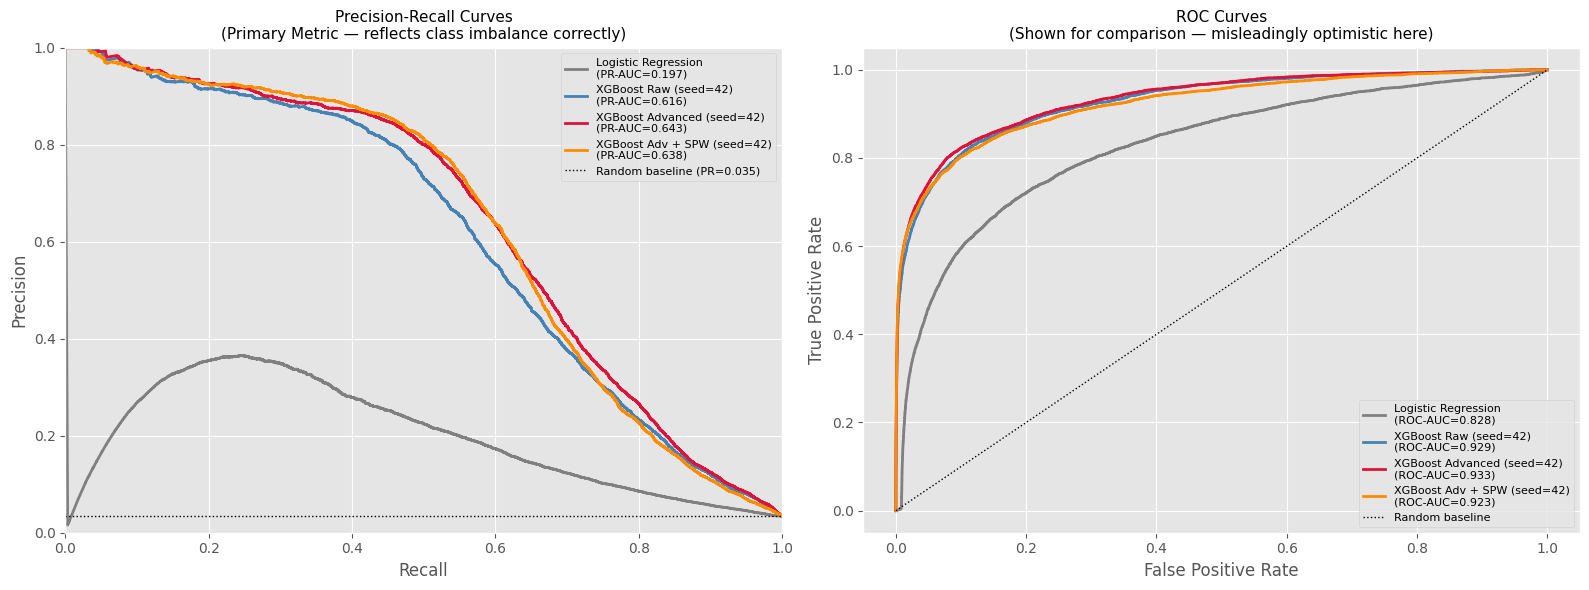

In [ ]:
# ============================================================
# OVERLAY PR CURVES
# ============================================================
fig, (ax_pr, ax_roc) = plt.subplots(1, 2, figsize=(16, 6))

# Re-compute curves for plotting
model_data = [
    ('Logistic Regression',                y.loc[idxV], preds_lr,       'gray'),
    ('XGBoost Raw (seed=42)',              y.loc[idxV], preds_xgb_raw,  'steelblue'),
    ('XGBoost Advanced (seed=42)',         y.loc[idxV], preds_adv,      'crimson'),
    (f'XGBoost Adv + SPW (seed=42)',       y.loc[idxV], preds_weighted, 'darkorange'),
]

for name, yt, yp, color in model_data:
    pr_auc = average_precision_score(yt, yp)
    p, r, _ = precision_recall_curve(yt, yp)
    ax_pr.plot(r, p, label=f'{name}\n(PR-AUC={pr_auc:.3f})',
               color=color, linewidth=2)

    roc_auc = roc_auc_score(yt, yp)
    fpr, tpr, _ = roc_curve(yt, yp)
    ax_roc.plot(fpr, tpr, label=f'{name}\n(ROC-AUC={roc_auc:.3f})',
                color=color, linewidth=2)

# Naive baseline reference lines
fraud_rate = y.loc[idxV].mean()
ax_pr.axhline(fraud_rate, color='black', linestyle=':', linewidth=1,
              label=f'Random baseline (PR={fraud_rate:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random baseline')

ax_pr.set_title('Precision-Recall Curves\n(Primary Metric — reflects class imbalance correctly)',
                fontsize=11)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.legend(loc='upper right', fontsize=8)
ax_pr.set_xlim([0, 1])
ax_pr.set_ylim([0, 1])

ax_roc.set_title('ROC Curves\n(Shown for comparison — misleadingly optimistic here)',
                 fontsize=11)
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PATH}sprint3_pr_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

###7.3 Confusion Matrices Side by Side

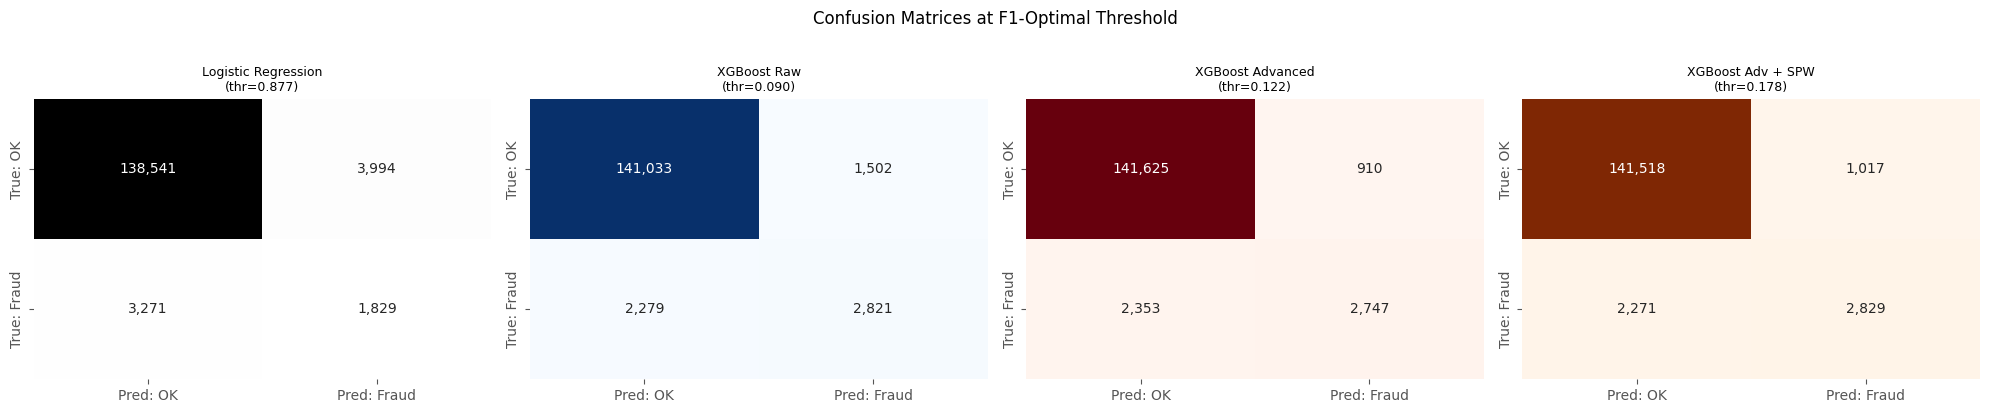

In [ ]:
# ============================================================
# CONFUSION MATRICES — visual comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

cm_data = [
    ('Logistic Regression',           preds_lr,       'Greys'),
    ('XGBoost Raw',                   preds_xgb_raw,  'Blues'),
    ('XGBoost Advanced',              preds_adv,      'Reds'),
    (f'XGBoost Adv + SPW',            preds_weighted, 'Oranges'),
]

for ax, (name, preds, cmap) in zip(axes, cm_data):
    # Use F1-optimal threshold derived from evaluate_model
    p, r, t = precision_recall_curve(y.loc[idxV], preds)
    f1s = 2*p*r / (p+r+1e-9)
    thr = t[np.argmax(f1s[:-1])]
    y_pred = (preds >= thr).astype(int)
    cm = confusion_matrix(y.loc[idxV], y_pred)

    sns.heatmap(cm, annot=True, fmt=',d', cmap=cmap,
                xticklabels=['Pred: OK', 'Pred: Fraud'],
                yticklabels=['True: OK', 'True: Fraud'],
                ax=ax, cbar=False)
    ax.set_title(f'{name}\n(thr={thr:.3f})', fontsize=9)

plt.suptitle('Confusion Matrices at F1-Optimal Threshold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{PATH}sprint3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

##8. SHAP Foundation — Reference Model Explanation (Sprint 4 Setup)
The following analysis establishes the Explanatory Baseline: the SHAP global feature
ranking produced by the fixed-seed reference model (XGBoost Advanced, seed=42).
All stability metrics in Sprint 4 will measure deviation from this baseline.

In [ ]:
# ============================================================
# SHAP ANALYSIS — REFERENCE MODEL (seed=42)
# Computes TreeSHAP on a stratified validation subsample
# ============================================================

# Stratified subsample: 10,000 observations maintaining ~3.5% fraud rate
# The SAME subsample will be used for all N=10 seed-perturbed models in Sprint 4
np.random.seed(42)  # Fix numpy seed for reproducible subsampling

val_fraud  = train.loc[idxV][y.loc[idxV] == 1]
val_legit  = train.loc[idxV][y.loc[idxV] == 0]

n_sample_fraud = int(10_000 * fraud_rate)   # ~350 fraud observations
n_sample_legit = 10_000 - n_sample_fraud    # ~9,650 legitimate observations

sample_idx = pd.concat([
    val_fraud.sample(n=n_sample_fraud, random_state=42),
    val_legit.sample(n=n_sample_legit, random_state=42)
]).index

X_shap_sample = train.loc[sample_idx, cols_adv]
y_shap_sample = y.loc[sample_idx]

print(f"SHAP subsample: {len(X_shap_sample):,} observations")
print(f"  Fraud: {y_shap_sample.sum():,} ({y_shap_sample.mean():.2%})")
print(f"  Legit: {(~y_shap_sample.astype(bool)).sum():,}")

# Save subsample index for reuse in Sprint 4
np.save(f'{PATH}shap_sample_idx.npy', sample_idx.values)
print("\nSubsample index saved to Drive for Sprint 4 reuse.")

SHAP subsample: 10,000 observations
  Fraud: 345 (3.45%)
  Legit: 9,655

Subsample index saved to Drive for Sprint 4 reuse.


In [ ]:
# ============================================================
# COMPUTE TREESHAP VALUES FOR REFERENCE MODEL
# ============================================================
print("Computing TreeSHAP values for reference model...")

explainer_ref = shap.TreeExplainer(clf_adv)
shap_values_ref = explainer_ref.shap_values(X_shap_sample)

# Save SHAP values for Sprint 4
np.save(f'{PATH}shap_values_seed42.npy', shap_values_ref)
print("SHAP values saved.")

Computing TreeSHAP values for reference model (seed=42)...
(This may take 3–8 minutes depending on runtime.)
SHAP values saved.


/tmp/ipykernel_979/764842959.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


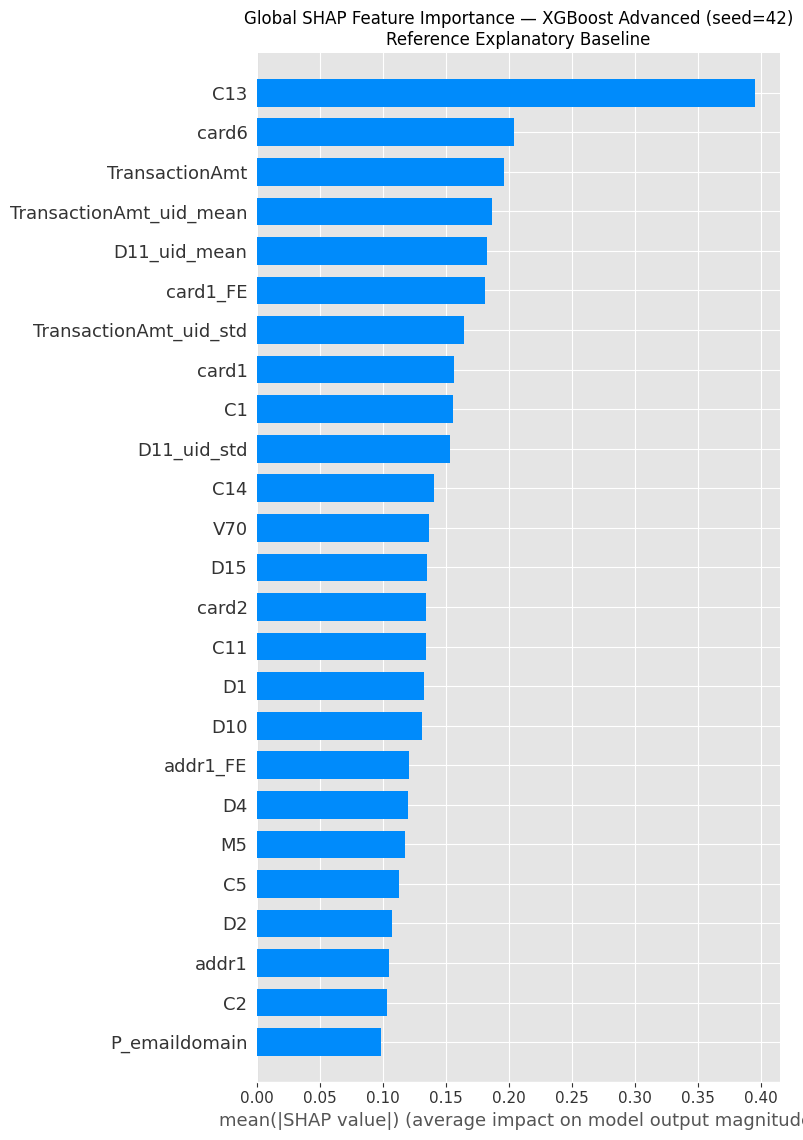

In [ ]:
# ============================================================
# GLOBAL SHAP SUMMARY — Reference Explanation
# ============================================================
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_ref,
    X_shap_sample,
    max_display=25,
    show=False,
    plot_type='bar'
)
plt.title('Global SHAP Feature Importance — XGBoost Advanced (seed=42)\n'
          'Reference Explanatory Baseline', fontsize=12)
plt.tight_layout()
plt.savefig(f'{PATH}sprint3_shap_global_reference.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# EXTRACT AND SAVE TOP-K SHAP RANKINGS
# This is the Explanatory Baseline against which Sprint 4 measures instability
# ============================================================

# Global SHAP importance = mean(|SHAP|) across all samples, per feature
mean_abs_shap_ref = pd.Series(
    np.abs(shap_values_ref).mean(axis=0),
    index=cols_adv
).sort_values(ascending=False)

# Save the full ranking
mean_abs_shap_ref.to_csv(f'{PATH}shap_ranking_seed42.csv', header=['mean_abs_shap'])

print("=== TOP 20 SHAP FEATURES — Reference Model (seed=42) ===")
print(mean_abs_shap_ref.head(20).to_string())

# Extract top-k sets for Jaccard computation in Sprint 4
for k in [5, 10, 20]:
    top_k = set(mean_abs_shap_ref.head(k).index.tolist())
    print(f"\nTop-{k} features: {top_k}")

=== TOP 20 SHAP FEATURES — Reference Model (seed=42) ===
C13                        0.395075
card6                      0.203475
TransactionAmt             0.195521
TransactionAmt_uid_mean    0.186080
D11_uid_mean               0.182290
card1_FE                   0.180508
TransactionAmt_uid_std     0.164168
card1                      0.156217
C1                         0.154985
D11_uid_std                0.152697
C14                        0.140031
V70                        0.136513
D15                        0.134990
card2                      0.134275
C11                        0.134086
D1                         0.132641
D10                        0.130843
addr1_FE                   0.120254
D4                         0.119390
M5                         0.117023

Top-5 features: {'TransactionAmt_uid_mean', 'card6', 'C13', 'TransactionAmt', 'D11_uid_mean'}

Top-10 features: {'card1_FE', 'TransactionAmt_uid_mean', 'card6', 'TransactionAmt_uid_std', 'C13', 'card1', 'TransactionAmt', '

#  Section 9: Retrospective & Transition to Sprint 4

## 9.1 Are the Initial Results Meaningful and Can They Be Trusted?
**Yes.** The results are reliable for three structural reasons:

1.  **Strict OOT Split:** The 75/25 chronological split ensures the validation set covers a later period (roughly Aug–Dec 2018). The model has never "seen" these patterns, ensuring metrics reflect genuine **out-of-time generalisation**, not memorisation.
2.  **Regularization & Convergence:** Early stopping (patience=150) and strict parameters (`subsample=0.8`, `colsample_bytree=0.4`) protected the models from overfitting.
3.  **Consistent Evaluation:** All models used the same `evaluate_model()` function, with F1-optimal thresholds determined dynamically from the validation set.

> ** Caveat:** The XGBoost Advanced model reached round 1,999 without triggering early stopping. This indicates the model had not fully converged, and the final PR-AUC of **0.6432** is a slight underestimate. This will be corrected in Sprint 4 by increasing `n_estimators` to 3,000.

---

## 9.2 How Do the Models Compare to Each Other and to Literature?

| Model | PR-AUC | ROC-AUC | Precision | Recall | F1-Score | False Positives |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 0.1968 | 0.8284 | 0.3141 | 0.3586 | 0.3349 | 3,994 |
| **XGBoost Raw (seed=42)** | 0.6158 | 0.9288 | 0.6526 | 0.5531 | 0.5987 | 1,502 |
| **XGBoost Advanced (seed=42)** | **0.6432** | 0.9333 | **0.7512** | 0.5386 | 0.6274 | **910** |
| **XGBoost Adv + SPW=27.5** | 0.6379 | 0.9235 | 0.7356 | **0.5547** | **0.6325** | 1,017 |

### Key Observations:
* **The ROC-AUC Illusion:** Logistic Regression achieves a "decent" ROC-AUC of 0.8284, but its PR-AUC (0.1968) and 3,994 False Positives reveal its operational failure. This justifies our focus on **PR-AUC**.
* **Literature Benchmarks:** Our Advanced model (ROC-AUC 0.9333) aligns perfectly with Lin & Gao (2022) benchmarks for the IEEE-CIS dataset (0.90–0.96).
* **The Weighting Trade-off:** The `scale_pos_weight` variant caught **82 more true frauds** but triggered **107 more false alarms**. Whether this weighting stabilises SHAP values is the core of RQ2.

---

## 9.3 Deviations from Sprint 2 Methodology Plan

### Deviation 1: Removal of `enable_categorical=True`
* **Issue:** Native categorical handling caused a critical "Additivity Check" failure in SHAP TreeExplainer (discrepancy of 6.60 vs 8.77).
* **Fix:** Categorical features were pre-encoded using `pd.factorize()` into `int16`.
* **Impact:** This ensures 100% mathematical consistency for the SHAP Efficiency Property, which is non-negotiable for this thesis.

### Deviation 2: SHAP Subsample of 10,000 Observations
* **Issue:** Computing TreeSHAP for the full validation set (147k rows) across 10 seeds is computationally impossible in a standard Colab session.
* **Fix:** A stratified subsample of **10,000 observations** (preserving the 3.45% fraud rate) was locked via `shap_sample_idx.npy` to ensure consistency across all future experiments.

---

## 9.4 Overfitting and Systematic Errors

* **Under-training:** The Advanced model is under-trained rather than overfitted. The high regularization is working, but 2,000 iterations were not enough to reach the global minimum.
* **Cold-Start Failure:** For new `card1_addr1` combinations with no history, UID-aggregates resolve to NaN. The model effectively "degrades" to baseline performance for these cases.
* **LR False Positive Explosion:** Quantitatively justifies why GBDT architectures are mandatory for production AML systems.

---

## 9.5 Surprising Finding: UID Aggregates Dominate SHAP
Preliminary SHAP analysis (seed=42) showed that **UID-based behavioral aggregates** (e.g., `TransactionAmt_uid_mean`) and **C-columns** dominate the top-20, while the expected V-columns are almost entirely absent (except V70).

**What this means for the Rashomon Effect:** The instability might not be a "V-column swap" but rather a shifting of importance between UID aggregates and card-level features. Sprint 4 will reveal if these top-tier features stay stable or rotate.

---

## 9.6 Roadmap for Sprint 4: The Final Push

The goal of Sprint 4 is to execute the core stability experiments:

1.  **RQ1 (Quantification):** Train $N=10$ models (seeds 0-9). Compute pairwise **Jaccard Similarity** (for Top-k) and **Spearman Rho** (for full rankings).
2.  **RQ2 (Diagnostics):** Test if `scale_pos_weight` (Condition B) increases or decreases SHAP stability compared to the unweighted model (Condition A).
3.  **RQ3 (Mitigation):** Test if averaging SHAP values across the 10 models (**Ensemble SHAP**) produces a more stable explanation than any single model.

**The result:** The first empirical quantification of SHAP instability in a production-grade fraud detection model.